# LGBM (5 day constraint)

### imports

In [1]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from typing import Iterator, Optional
import random
from datetime import datetime
import lightgbm as lgb
import itertools

### load

In [2]:
df = pd.read_csv('consumption_temp.csv')
df.head(5)

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


## Prepare the data

### Preprocessing

From EDA, not much data preprocessing required. Type conversion, ensure sorting, filter to target consumption location

In [3]:
def preprocess_data(df, city, starting_date):
    """Basic preprocessing: filter by city, convert time to datetime, set index, sort, filter by starting date."""
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["time"])

    city_norm = city.strip().lower()
    df_city = df[df["location"].astype(str).str.strip().str.lower() == city_norm].copy()

    df_city = df_city.set_index("datetime").sort_index()
    df_city = df_city.loc[pd.Timestamp(starting_date):]

    return df_city


In [4]:
location_df = preprocess_data(df, city='bergen', starting_date='2022-08-01') 
location_df.head(5)

,time,location,consumption,temperature
datetime,,,,
2022-08-01 00:00:00,2022-08-01 00:00:00,bergen,0.730897,9.0
2022-08-01 01:00:00,2022-08-01 01:00:00,bergen,0.716152,9.5
2022-08-01 02:00:00,2022-08-01 02:00:00,bergen,0.721158,9.6
2022-08-01 03:00:00,2022-08-01 03:00:00,bergen,0.734186,9.5
2022-08-01 04:00:00,2022-08-01 04:00:00,bergen,0.785847,9.9


### feature engineering

**features added**

* Calendar: `is_weekend`
* Cyclical time encodings: `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos`, `woy_sin`, `woy_cos`
* Temperature (available in real time): `temp_lag_24`, `temp_lag_168`, `temp_roll_mean_24`, `temp_roll_std_24`, `temp_roll_mean_168`, `temp_roll_std_168`, `heating_degree_18`
* Consumption (respecting 5-day delay): `lag_120`, `lag_168`, `avail_roll_mean_168`, `avail_roll_std_168`, `avail_roll_mean_336`, `avail_roll_std_336`
  (rolling stats use `consumption.shift(120)` to avoid leakage)

**features removed**

* Redundant raw time columns: `hour`, `day_of_week`, `month`, `week_of_year`



In [5]:
def add_time_features(
    df: pd.DataFrame,
    *,
    target_col: str = "consumption",
    temp_col: str | None = "temperature",
    delay_days: int = 5,
    drop_cols: list[str] | None = None,
    add_cyclical: bool = True,
    add_consumption_lags: bool = True,
    add_consumption_rollings: bool = True,
    cons_lags: tuple[int, ...] = (120, 168),
    cons_rolling_windows: tuple[int, ...] = (168, 336),
    temp_lags: tuple[int, ...] = (24, 168),
    temp_rolling_windows: tuple[int, ...] = (24, 168),
) -> pd.DataFrame:
    """
    Feature engineering for hourly day-ahead. 5 day data delay on consumption.

    Returns a NEW dataframe.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("DataFrame index must be a DatetimeIndex.")

    out = df.copy()
    delay_h = int(delay_days * 24)

    # Basic calendar features (used for cyclical encodings)
    hour = out.index.hour
    dow = out.index.dayofweek
    month = out.index.month
    woy = out.index.isocalendar().week.astype(int)

    out["is_weekend"] = (dow >= 5).astype(int)
    out["hour"] = hour
    out["day_of_week"] = dow
    out["month"] = month
    out["week_of_year"] = woy

    # Cyclical encodings
    if add_cyclical:
        out["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
        out["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

        out["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
        out["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)

        out["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12.0)
        out["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12.0)

        out["woy_sin"] = np.sin(2 * np.pi * (woy - 1) / 52.0)
        out["woy_cos"] = np.cos(2 * np.pi * (woy - 1) / 52.0)

    # Temperature features 
    out[temp_col] = out[temp_col].astype(float)

    for k in temp_lags:
        out[f"temp_lag_{k}"] = out[temp_col].shift(k)

    shifted_temp = out[temp_col].shift(1)
    for w in temp_rolling_windows:
        out[f"temp_roll_mean_{w}"] = shifted_temp.rolling(window=w, min_periods=w).mean()
        out[f"temp_roll_std_{w}"]  = shifted_temp.rolling(window=w, min_periods=w).std()

    out["heating_degree_18"] = np.maximum(0.0, 18.0 - out[temp_col])

    # Consumption lag features, available with 5 day delay
    if add_consumption_lags:
        for k in cons_lags:
            out[f"lag_{k}"] = out[target_col].shift(k)

    # Consumption rolling stats
    if add_consumption_rollings:
        avail = out[target_col].shift(delay_h)
        for w in cons_rolling_windows:
            out[f"avail_roll_mean_{w}"] = avail.rolling(window=w, min_periods=w).mean()
            out[f"avail_roll_std_{w}"]  = avail.rolling(window=w, min_periods=w).std()

    # Drop redundant raw time columns
    out = out.drop(columns=[c for c in ["hour", "day_of_week", "month", "week_of_year"] if c in out.columns])

    # Optional drops
    if drop_cols:
        out = out.drop(columns=[c for c in drop_cols if c in out.columns])

    return out


In [6]:
# Feature engineering cell
data = location_df.copy()

data = add_time_features(
    data,
    target_col="consumption",
    temp_col="temperature",
    delay_days=5,
    drop_cols=["time", "location", "datetime"],
    cons_lags=(120, 168), # safe under 5-day delay data constraint
    cons_rolling_windows=(168, 336),
    temp_lags=(24, 168),
    temp_rolling_windows=(24, 168),
)

# drop NaNs introduced by lag/rolling features
data = data.dropna()

data.head(5)

,consumption,temperature,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,woy_sin,...,temp_roll_std_24,temp_roll_mean_168,temp_roll_std_168,heating_degree_18,lag_120,lag_168,avail_roll_mean_168,avail_roll_std_168,avail_roll_mean_336,avail_roll_std_336
datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-19 23:00:00,0.790461,12.5,0,-0.258819,0.965926,-0.433884,-0.900969,-0.5,-0.866025,-0.663123,...,2.240499,16.776786,4.022228,5.5,0.752648,0.804632,0.901162,0.137629,0.915201,0.146364
2022-08-20 00:00:00,0.734402,11.8,1,0.000000,1.000000,-0.974928,-0.222521,-0.5,-0.866025,-0.663123,...,2.275448,16.783333,4.014311,6.2,0.658317,0.767826,0.900023,0.138844,0.914985,0.146690
2022-08-20 01:00:00,0.715569,13.3,1,0.258819,0.965926,-0.974928,-0.222521,-0.5,-0.866025,-0.663123,...,2.335594,16.786905,4.009578,4.7,0.625492,0.729298,0.898776,0.140364,0.914715,0.147140
2022-08-20 02:00:00,0.689392,13.1,1,0.500000,0.866025,-0.974928,-0.222521,-0.5,-0.866025,-0.663123,...,2.356117,16.795238,4.000805,4.9,0.617041,0.704031,0.897597,0.141895,0.914406,0.147657
2022-08-20 03:00:00,0.701503,12.3,1,0.707107,0.707107,-0.974928,-0.222521,-0.5,-0.866025,-0.663123,...,2.381903,16.803571,3.991576,5.7,0.629022,0.690910,0.896401,0.143308,0.914093,0.148151


### split the data

We split the time series into **sliding day-ahead windows**. For each forecast day, we train on a fixed **180-day history** and tune hyperparameters using the **14 days immediately before** the test window. During the final 14-day test, we retrain and predict **one day at a time** to mimic real deployment.


In [7]:
from dataclasses import dataclass
from typing import Iterator
import pandas as pd


@dataclass
class SlidingSplit:
    forecast_date: pd.Timestamp
    # boundaries (useful for logging/debug)
    train_start: pd.Timestamp
    train_end: pd.Timestamp       # exclusive
    val_start: pd.Timestamp
    val_end: pd.Timestamp         # exclusive
    test_start: pd.Timestamp
    test_end: pd.Timestamp        # exclusive
    # availability cutoff used for this forecast day
    avail_end_day: pd.Timestamp   # latest available consumption day (day-level)
    # data
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series


def iter_sliding_day_ahead_splits(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: list[str],
    *,
    last_complete_day: str = "2023-04-01",
    test_days: int = 14,
    history_days: int = 180,   # train+val horizon (sliding), counted on AVAILABLE history
    val_days: int = 14,        # inside the available history window
    delay_days: int = 5,       # consumption availability delay
    include_day_d_minus_delay: bool = True,  # if True, day D-delay is assumed available
) -> Iterator[SlidingSplit]:
    """
    Leakage-safe sliding splits for day-ahead forecasting with delayed target availability.

    For each forecast day D:
      - test slice = [D, D+1)
      - latest available consumption is day (D - delay_days) if include_day_d_minus_delay=True
        else day (D - delay_days - 1)
      - history window is built from AVAILABLE history only (ends before unavailable gap)
      - validation = last `val_days` inside available history
      - training = earlier part of available history

    This ensures we do NOT train/validate using target rows that would be unavailable at forecast time.
    """
    df = df.sort_index()

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("df.index must be a DatetimeIndex")

    tz = df.index.tz

    def _ts_day(s: str) -> pd.Timestamp:
        t = pd.Timestamp(s)
        if tz is not None:
            t = t.tz_localize(tz) if t.tzinfo is None else t.tz_convert(tz)
        else:
            if t.tzinfo is not None:
                t = t.tz_convert(None)
        return t.normalize()

    last_complete = _ts_day(last_complete_day)

    # Keep only data up to the stated last complete day (inclusive at day level)
    df = df.loc[: last_complete + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)]

    # Define test forecast days (inclusive)
    test_start_day = last_complete - pd.Timedelta(days=test_days - 1)
    test_days_range = pd.date_range(test_start_day, last_complete, freq="D", tz=tz)

    first_day_in_df = df.index.min().normalize()
    last_day_in_df = df.index.max().normalize()

    for D in test_days_range:
        test_start = D
        test_end = D + pd.Timedelta(days=1)

        # --- Availability cutoff for consumption labels when forecasting day D ---
        if include_day_d_minus_delay:
            avail_end_day = D - pd.Timedelta(days=delay_days)      # inclusive day-level
        else:
            avail_end_day = D - pd.Timedelta(days=delay_days + 1)  # stricter convention

        # If availability cutoff is before the dataset starts, cannot build split
        if avail_end_day < first_day_in_df:
            print(f"Skipping split for {D.date()} (availability cutoff before dataset start).")
            continue

        # Available history ends at END of avail_end_day => exclusive timestamp = next day midnight
        avail_hist_end = avail_end_day + pd.Timedelta(days=1)  # exclusive

        # History window is [hist_start, avail_hist_end)
        hist_end = avail_hist_end
        hist_start = hist_end - pd.Timedelta(days=history_days)
        hist_start = max(hist_start, first_day_in_df)

        # Validation is the last val_days of AVAILABLE history
        val_end = hist_end  # exclusive
        val_start = val_end - pd.Timedelta(days=val_days)
        val_start = max(val_start, hist_start)

        # Training is earlier available history
        train_start = hist_start
        train_end = val_start  # exclusive

        # Hourly slices (all end bounds are exclusive, so subtract 1 hour in .loc)
        train_slice = df.loc[train_start : train_end - pd.Timedelta(hours=1)]
        val_slice   = df.loc[val_start   : val_end   - pd.Timedelta(hours=1)]
        test_slice  = df.loc[test_start  : test_end  - pd.Timedelta(hours=1)]

        # Safety checks
        if train_slice.empty or val_slice.empty or test_slice.empty:
            print(f"Skipping split for {D.date()} due to insufficient data coverage.")
            continue

        # Optional sanity check for full-day hourly coverage (24 rows)
        # Comment out if your data has missing hours and you intentionally allow that.
        if len(test_slice) < 24:
            print(f"Skipping split for {D.date()} due to incomplete test day ({len(test_slice)} rows).")
            continue

        yield SlidingSplit(
            forecast_date=D,
            train_start=train_start, train_end=train_end,
            val_start=val_start, val_end=val_end,
            test_start=test_start, test_end=test_end,
            avail_end_day=avail_end_day,
            X_train=train_slice[feature_cols],
            y_train=train_slice[target_col],
            X_val=val_slice[feature_cols],
            y_val=val_slice[target_col],
            X_test=test_slice[feature_cols],
            y_test=test_slice[target_col],
        )


# =====================
# Build leakage-safe test splits
# =====================
target_col = "consumption"
feature_cols = [c for c in data.columns if c != target_col]

splits = list(iter_sliding_day_ahead_splits(
    data,
    target_col=target_col,
    feature_cols=feature_cols,
    last_complete_day="2023-04-01",
    test_days=14,
    history_days=180,
    val_days=14,
    delay_days=5,
    include_day_d_minus_delay=True,   # adjust if your operational timing is stricter
))

print("Num test days:", len(splits))
print("Test window:", splits[0].forecast_date.date(), "->", splits[-1].forecast_date.date())

# Debug first split
s0 = splits[0]
print("\nFirst split (leakage-safe):")
print("  forecast day:", s0.forecast_date.date())
print("  latest available consumption day:", s0.avail_end_day.date())
print("  train:", s0.train_start.date(), "->", (s0.train_end - pd.Timedelta(days=1)).date(), "(exclusive end =", s0.train_end.date(), ")")
print("  val  :", s0.val_start.date(),   "->", (s0.val_end   - pd.Timedelta(days=1)).date(), "(exclusive end =", s0.val_end.date(), ")")
print("  test :", s0.test_start.date(),  "->", (s0.test_end  - pd.Timedelta(days=1)).date(), "(exclusive end =", s0.test_end.date(), ")")
print("  rows  train/val/test:", len(s0.X_train), len(s0.X_val), len(s0.X_test))

# Quick sanity check across all splits: latest available day should equal forecast_day - 5 days
print("\nSanity checks (first 3 / last 3):")
for s in (splits[:3] + splits[-3:]):
    expected = (s.forecast_date - pd.Timedelta(days=5)).date()
    print(
        f"  D={s.forecast_date.date()} | avail_end_day={s.avail_end_day.date()} | expected={expected}"
    )

Num test days: 14
Test window: 2023-03-19 -> 2023-04-01

First split (leakage-safe):
  forecast day: 2023-03-19
  latest available consumption day: 2023-03-14
  train: 2022-09-16 -> 2023-02-28 (exclusive end = 2023-03-01 )
  val  : 2023-03-01 -> 2023-03-14 (exclusive end = 2023-03-15 )
  test : 2023-03-19 -> 2023-03-19 (exclusive end = 2023-03-20 )
  rows  train/val/test: 3984 336 24

Sanity checks (first 3 / last 3):
  D=2023-03-19 | avail_end_day=2023-03-14 | expected=2023-03-14
  D=2023-03-20 | avail_end_day=2023-03-15 | expected=2023-03-15
  D=2023-03-21 | avail_end_day=2023-03-16 | expected=2023-03-16
  D=2023-03-30 | avail_end_day=2023-03-25 | expected=2023-03-25
  D=2023-03-31 | avail_end_day=2023-03-26 | expected=2023-03-26
  D=2023-04-01 | avail_end_day=2023-03-27 | expected=2023-03-27


## Train

### model architecture

In [8]:
# Model + utilities
def make_lgbm_model(params: dict | None = None) -> lgb.LGBMRegressor:
    """Create a LightGBM regressor with default parameters, optionally updated by `params`."""
    base = dict(
        objective="regression",
        boosting_type="gbdt",
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=50,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    if params: base.update(params)
    return lgb.LGBMRegressor(**base)

def mae(y_true, y_pred) -> float:
    """Mean Absolute Error."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred) -> float:
    """Root Mean Squared Error."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def smape(y_true, y_pred, eps: float = 1e-9) -> float:
    """Symmetric Mean Absolute Percentage Error."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom)) * 100.0

def log(msg: str) -> None:
    """Simple logger with timestamp."""
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}")

def grid(space: dict) -> list[dict]:
    """Generate a list of parameter combinations from a grid dictionary."""
    keys = list(space.keys())
    return [dict(zip(keys, vals)) for vals in itertools.product(*[space[k] for k in keys])]

### setup

In [9]:
# Fit/predict helper
def fit_predict(split, params: dict, *, mode: str):
    """
    mode="val": fit on train, predict val
    mode="test": fit on train+val, predict test (no early stopping)
    """
    model = make_lgbm_model(params)

    if mode == "val":
        model.fit(
            split.X_train, split.y_train,
            eval_set=[(split.X_val, split.y_val)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(100, verbose=False)],
        )
        return model.predict(split.X_val)

    if mode == "test":
        X_fit = pd.concat([split.X_train, split.X_val], axis=0)
        y_fit = pd.concat([split.y_train, split.y_val], axis=0)
        model.fit(X_fit, y_fit)
        return model.predict(split.X_test)

    raise ValueError("mode must be 'val' or 'test'")

In [10]:
# =========================
# Splits: TEST + TUNE (adjacent, leakage-safe with delay)
# =========================
target_col = "consumption"
feature_cols = [c for c in data.columns if c != target_col]

DELAY_DAYS = 5
TEST_DAYS = 14
HISTORY_DAYS = 180
VAL_DAYS = 14
LAST_COMPLETE_TEST_DAY = "2023-04-01"

# --- Build TEST splits ---
test_splits = list(iter_sliding_day_ahead_splits(
    data,
    target_col=target_col,
    feature_cols=feature_cols,
    last_complete_day=LAST_COMPLETE_TEST_DAY,
    test_days=TEST_DAYS,
    history_days=HISTORY_DAYS,
    val_days=VAL_DAYS,
    delay_days=DELAY_DAYS,
    include_day_d_minus_delay=True,   # set False if your ops timing means D-5 is not yet available
))

if not test_splits:
    raise ValueError("No test_splits were created. Check data coverage and split parameters.")

# TEST forecast horizon
test_start = test_splits[0].forecast_date.normalize()
test_end   = test_splits[-1].forecast_date.normalize()

# --- Build TUNE splits (the 14 forecast days immediately before TEST horizon) ---
# If TEST starts at day T0, TUNE should end at T0-1 and span TEST_DAYS days.
tune_last_complete = (test_start - pd.Timedelta(days=1)).normalize()

tune_splits = list(iter_sliding_day_ahead_splits(
    data,
    target_col=target_col,
    feature_cols=feature_cols,
    last_complete_day=str(tune_last_complete.date()),
    test_days=TEST_DAYS,        # tuning horizon length (same as test horizon)
    history_days=HISTORY_DAYS,
    val_days=VAL_DAYS,
    delay_days=DELAY_DAYS,
    include_day_d_minus_delay=True,
))

if not tune_splits:
    raise ValueError("No tune_splits were created. Check data coverage and split parameters.")

tune_start = tune_splits[0].forecast_date.normalize()
tune_end   = tune_splits[-1].forecast_date.normalize()

# --- Logging ---
log(f"TUNE forecast days: {tune_start.date()} -> {tune_end.date()} ({len(tune_splits)} days)")
log(f"TEST forecast days: {test_start.date()} -> {test_end.date()} ({len(test_splits)} days)")

# Optional sanity checks for leakage-safe cutoffs
for label, splits_ in [("TUNE", tune_splits), ("TEST", test_splits)]:
    s0 = splits_[0]
    sN = splits_[-1]
    log(
        f"{label} first split: D={s0.forecast_date.date()} "
        f"avail_end={s0.avail_end_day.date()} "
        f"train_end_excl={s0.train_end.date()} val_end_excl={s0.val_end.date()}"
    )
    log(
        f"{label} last split:  D={sN.forecast_date.date()} "
        f"avail_end={sN.avail_end_day.date()} "
        f"train_end_excl={sN.train_end.date()} val_end_excl={sN.val_end.date()}"
    )

# Stronger adjacency check (forecast horizons should be adjacent)
assert tune_splits[-1].forecast_date + pd.Timedelta(days=1) == test_splits[0].forecast_date, \
    "Tune/test forecast horizons are not adjacent as intended."

# Delay sanity check (first few + last few)
for s in (test_splits[:2] + test_splits[-2:]):
    expected = (s.forecast_date - pd.Timedelta(days=DELAY_DAYS)).date()
    assert s.avail_end_day.date() == expected, (
        f"Leakage check failed for {s.forecast_date.date()}: "
        f"avail_end_day={s.avail_end_day.date()} expected={expected}"
    )

[14:38:21] TUNE forecast days: 2023-03-05 -> 2023-03-18 (14 days)
[14:38:21] TEST forecast days: 2023-03-19 -> 2023-04-01 (14 days)
[14:38:21] TUNE first split: D=2023-03-05 avail_end=2023-02-28 train_end_excl=2023-02-15 val_end_excl=2023-03-01
[14:38:21] TUNE last split:  D=2023-03-18 avail_end=2023-03-13 train_end_excl=2023-02-28 val_end_excl=2023-03-14
[14:38:21] TEST first split: D=2023-03-19 avail_end=2023-03-14 train_end_excl=2023-03-01 val_end_excl=2023-03-15
[14:38:21] TEST last split:  D=2023-04-01 avail_end=2023-03-27 train_end_excl=2023-03-14 val_end_excl=2023-03-28


### tuning loop

We tune hyperparameters on a **separate tuning horizon** (the 14 days right before the test period) using walk-forward validation: for each day, we train on that day’s training slice and evaluate on its validation slice. We first run a **coarse grid search** to find a good region of parameters, then do a **small refined search** around the best coarse candidates. The best configuration is then frozen and used for the final retrain-and-test backtest.


In [11]:
# Two-stage tune over hyper parameters
coarse_space = {
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 63, 127],
    "min_child_samples": [20, 50, 100],
    "reg_lambda": [0.0, 1e-2, 1e-1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_alpha": [0.0],
}

def score_on_tune(params: dict, log_every: int = 5) -> float:
    scores = []
    for i, split in enumerate(tune_splits, start=1):
        # IMPORTANT: fit_predict(..., mode="val") must fit ONLY on split.X_train/split.y_train
        yhat = fit_predict(split, params, mode="val")
        s = mae(split.y_val.values, yhat)
        scores.append(s)

        if log_every and (i == 1 or i == len(tune_splits) or i % log_every == 0):
            log(
                f"  tune {i:>2}/{len(tune_splits)} "
                f"day={split.forecast_date.date()} "
                f"avail_end={split.avail_end_day.date()} "
                f"MAE={s:.4f}"
            )
    return float(np.mean(scores))


# --- Stage A: coarse grid ---
log("Stage A: coarse grid")

coarse_params_list = grid(coarse_space)  # compute once
n_coarse = len(coarse_params_list)

coarse_rows = []
for i, p in enumerate(coarse_params_list, start=1):
    if i == 1 or i == n_coarse or i % 10 == 0:
        log(f"  coarse {i}/{n_coarse} params={p}")

    coarse_rows.append({
        "stage": "coarse",
        "score": score_on_tune(p, log_every=0),
        **p
    })

coarse_df = pd.DataFrame(coarse_rows).sort_values("score").reset_index(drop=True)

top_k = 3
top = coarse_df.head(top_k).to_dict(orient="records")
log(f"Best coarse score: {coarse_df.loc[0, 'score']:.4f}")


def refine_space_2point(base: dict) -> dict:
    # Small local neighborhood: usually 2 values each => ~16 configs
    lr = float(base["learning_rate"])
    leaves = int(base["num_leaves"])
    mcs = int(base["min_child_samples"])
    rl = float(base["reg_lambda"])

    def twop(v, alt, lo, hi):
        alt = max(lo, min(hi, alt))
        return sorted(set([v, alt]))

    return {
        "learning_rate": twop(lr, lr * 0.8, 0.005, 0.2),
        "num_leaves": twop(leaves, leaves + 16, 15, 255),
        "min_child_samples": twop(mcs, mcs + 20, 5, 300),
        "reg_lambda": twop(rl, (rl * 10.0 if rl > 0 else 0.1), 0.0, 10.0),
        "subsample": [base["subsample"]],
        "colsample_bytree": [base["colsample_bytree"]],
        "reg_alpha": [base["reg_alpha"]],
    }


# --- Stage B: refine around best coarse configs ---
log("Stage B: refine around best coarse configs")

ref_rows = []
seen_refine = set()  # optional dedup across overlapping neighborhoods

for c in top:
    base = {k: c[k] for k in coarse_space.keys()}
    ref_list = grid(refine_space_2point(base))
    log(f"  refining {len(ref_list)} configs around {base}")

    for p in ref_list:
        key = tuple(sorted(p.items()))
        if key in seen_refine:
            continue
        seen_refine.add(key)

        ref_rows.append({
            "stage": "refine",
            "score": score_on_tune(p, log_every=0),
            **p
        })

ref_df = pd.DataFrame(ref_rows).sort_values("score").reset_index(drop=True)

# Combine all tuning results
tune_results = (
    pd.concat([coarse_df, ref_df], ignore_index=True)
    .sort_values("score")
    .reset_index(drop=True)
)

best_params = tune_results.iloc[0].drop(labels=["stage", "score"]).to_dict()
log(f"Best params: {best_params} (MAE={tune_results.loc[0, 'score']:.4f})")

display(tune_results.head(10))

[14:41:54] Stage A: coarse grid
[14:41:54]   coarse 1/54 params={'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 20, 'reg_lambda': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0}
[14:43:24]   coarse 10/54 params={'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 20, 'reg_lambda': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0}
[14:44:34]   coarse 20/54 params={'learning_rate': 0.03, 'num_leaves': 127, 'min_child_samples': 20, 'reg_lambda': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0}
[14:45:39]   coarse 30/54 params={'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20, 'reg_lambda': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0}
[14:46:12]   coarse 40/54 params={'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 50, 'reg_lambda': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0}
[14:46:58]   coarse 50/54 params={'learning_rate': 0.05, 'num_leave

,stage,score,learning_rate,num_leaves,min_child_samples,reg_lambda,subsample,colsample_bytree,reg_alpha
0,refine,0.173632,0.030,79,20,0.00,0.8,0.8,0.0
1,refine,0.173759,0.024,79,20,0.01,0.8,0.8,0.0
2,refine,0.173858,0.030,79,20,0.01,0.8,0.8,0.0
3,refine,0.173902,0.030,79,20,0.10,0.8,0.8,0.0
4,refine,0.174057,0.024,79,20,0.00,0.8,0.8,0.0
5,refine,0.174153,0.024,79,20,0.10,0.8,0.8,0.0
6,refine,0.174547,0.024,63,20,0.00,0.8,0.8,0.0
7,refine,0.174756,0.024,63,20,0.01,0.8,0.8,0.0
8,coarse,0.174854,0.030,63,20,0.10,0.8,0.8,0.0
9,refine,0.174854,0.030,63,20,0.10,0.8,0.8,0.0


### prediction / test

After tuning, we **freeze the best hyperparameters** and evaluate on the final **14-day test window** using day-ahead walk-forward forecasting. For each test day, we retrain the model on all available history (**train + validation**) and predict the next 24 hours. We collect predictions and compute daily and overall metrics (MAE, RMSE, SMAPE) to measure performance.


In [12]:
# Test backtest (walk-forward day-ahead, leakage-safe)
pred_rows, daily_rows = [], []
log("Running TEST backtest (retrain daily on available history = train+val)")

for i, split in enumerate(test_splits, start=1):
    # IMPORTANT: mode='test' should fit on split.X_train + split.X_val only (not anything beyond split boundaries)
    y_pred = fit_predict(split, best_params, mode="test")
    y_true = split.y_test.values

    daily_rows.append({
        "forecast_date": split.forecast_date,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "SMAPE_%": smape(y_true, y_pred),
    })

    pred_rows.append(pd.DataFrame({
        "forecast_date": split.forecast_date,
        "timestamp": split.X_test.index,
        "y_true": y_true,
        "y_pred": y_pred,
    }))

    log(
        f"  TEST {i:>2}/{len(test_splits)} "
        f"day={split.forecast_date.date()} "
        f"avail_end={split.avail_end_day.date()} "
        f"MAE={daily_rows[-1]['MAE']:.4f} "
        f"RMSE={daily_rows[-1]['RMSE']:.4f}"
    )

if not daily_rows:
    raise ValueError("No test predictions were produced. Check test_splits / data coverage.")

daily_metrics = pd.DataFrame(daily_rows).sort_values("forecast_date").reset_index(drop=True)
predictions = pd.concat(pred_rows, ignore_index=True)

log(f"Overall MAE:   {daily_metrics['MAE'].mean():.4f}")
log(f"Overall RMSE:  {daily_metrics['RMSE'].mean():.4f}")
log(f"Overall SMAPE: {daily_metrics['SMAPE_%'].mean():.2f}%")

display(daily_metrics)
predictions.head()

[14:51:43] Running TEST backtest (retrain daily on available history = train+val)
[14:51:54]   TEST  1/14 day=2023-03-19 avail_end=2023-03-14 MAE=0.1774 RMSE=0.2054
[14:51:59]   TEST  2/14 day=2023-03-20 avail_end=2023-03-15 MAE=0.2958 RMSE=0.3200
[14:52:04]   TEST  3/14 day=2023-03-21 avail_end=2023-03-16 MAE=0.1346 RMSE=0.1484
[14:52:08]   TEST  4/14 day=2023-03-22 avail_end=2023-03-17 MAE=0.1704 RMSE=0.1893
[14:52:13]   TEST  5/14 day=2023-03-23 avail_end=2023-03-18 MAE=0.2638 RMSE=0.2772
[14:52:18]   TEST  6/14 day=2023-03-24 avail_end=2023-03-19 MAE=0.3351 RMSE=0.3428
[14:52:23]   TEST  7/14 day=2023-03-25 avail_end=2023-03-20 MAE=0.1483 RMSE=0.1838
[14:52:28]   TEST  8/14 day=2023-03-26 avail_end=2023-03-21 MAE=0.2220 RMSE=0.2548
[14:52:33]   TEST  9/14 day=2023-03-27 avail_end=2023-03-22 MAE=0.2801 RMSE=0.3009
[14:52:37]   TEST 10/14 day=2023-03-28 avail_end=2023-03-23 MAE=0.1321 RMSE=0.1642
[14:52:42]   TEST 11/14 day=2023-03-29 avail_end=2023-03-24 MAE=0.1652 RMSE=0.1924
[14:5

,forecast_date,MAE,RMSE,SMAPE_%
0,2023-03-19,0.177375,0.205436,6.220921
1,2023-03-20,0.295760,0.320002,10.661427
2,2023-03-21,0.134589,0.148428,4.670285
3,2023-03-22,0.170385,0.189338,6.220141
4,2023-03-23,0.263845,0.277159,9.587254
5,2023-03-24,0.335087,0.342846,11.906428
6,2023-03-25,0.148299,0.183844,5.554321
7,2023-03-26,0.222008,0.254848,7.198488
8,2023-03-27,0.280121,0.300893,9.558115
9,2023-03-28,0.132104,0.164211,4.339732


,forecast_date,timestamp,y_true,y_pred
0,2023-03-19,2023-03-19 00:00:00,2.589399,2.820415
1,2023-03-19,2023-03-19 01:00:00,2.504455,2.701737
2,2023-03-19,2023-03-19 02:00:00,2.445723,2.640692
3,2023-03-19,2023-03-19 03:00:00,2.400561,2.618933
4,2023-03-19,2023-03-19 04:00:00,2.341152,2.628102


### baseline, optimistic previous day prediction

In [13]:
def baseline_day_ahead_predict_sliding(
    df: pd.DataFrame,
    target_col: str,
    *,
    last_complete_day: str = "2023-04-01",
    test_days: int = 14,
    history_days: int = 180,
    val_days: int = 14,
) -> pd.DataFrame:
    """
    Optimistic baseline, predict day D using same clock hour from previous day (D-1).
    Day before consumption values are not actually available at prediction time
    """
    df = df.sort_index()

    # splitter needs feature_cols, but baseline doesn't use them
    feature_cols_dummy = [c for c in df.columns if c != target_col]

    splits = list(iter_sliding_day_ahead_splits(
        df,
        target_col=target_col,
        feature_cols=feature_cols_dummy,
        last_complete_day=last_complete_day,
        test_days=test_days,
        history_days=history_days,
        val_days=val_days,
    ))

    preds = []

    for split in splits:
        # Forecast timestamps for day D (hourly)
        ts = split.X_test.index

        # Yesterday timestamps (same clock hour, previous day)
        ts_prev = ts - pd.Timedelta(days=1)

        # Pull yesterday's values hour-by-hour
        y_pred = df[target_col].reindex(ts_prev).to_numpy()

        # Safety fallback if any missing
        # (e.g. missing hours) -> fill with last observed training value
        if np.isnan(y_pred).any():
            fallback = float(split.y_train.iloc[-1])
            y_pred = np.where(np.isnan(y_pred), fallback, y_pred)

        preds.append(pd.DataFrame({
            "forecast_date": split.forecast_date,
            "timestamp": ts,
            "y_true": split.y_test.values,
            "y_pred": y_pred,
        }))

    return pd.concat(preds, ignore_index=True)


In [14]:
# Test the baseline on the test window

target_col = "consumption"

baseline_predictions = baseline_day_ahead_predict_sliding(
    df=data,
    target_col=target_col,
    last_complete_day="2023-04-01",
    test_days=14,
    history_days=180,
    val_days=14,
)

log(f"Baseline test window: {baseline_predictions['forecast_date'].min().date()} "
    f"-> {baseline_predictions['forecast_date'].max().date()} "
    f"({baseline_predictions['forecast_date'].nunique()} days)")

# Metrics
baseline_mae = mae(baseline_predictions["y_true"].values, baseline_predictions["y_pred"].values)
log(f"Baseline MAE:   {baseline_mae:.4f}")

baseline_rmse = rmse(baseline_predictions["y_true"].values, baseline_predictions["y_pred"].values)
log(f"Baseline RMSE:  {baseline_rmse:.4f}")

baseline_smape = smape(baseline_predictions["y_true"].values, baseline_predictions["y_pred"].values)
log(f"Baseline SMAPE: {baseline_smape:.2f}%")


[14:57:09] Baseline test window: 2023-03-19 -> 2023-04-01 (14 days)
[14:57:09] Baseline MAE:   0.2137
[14:57:09] Baseline RMSE:  0.2749
[14:57:09] Baseline SMAPE: 7.49%


### Visualize results

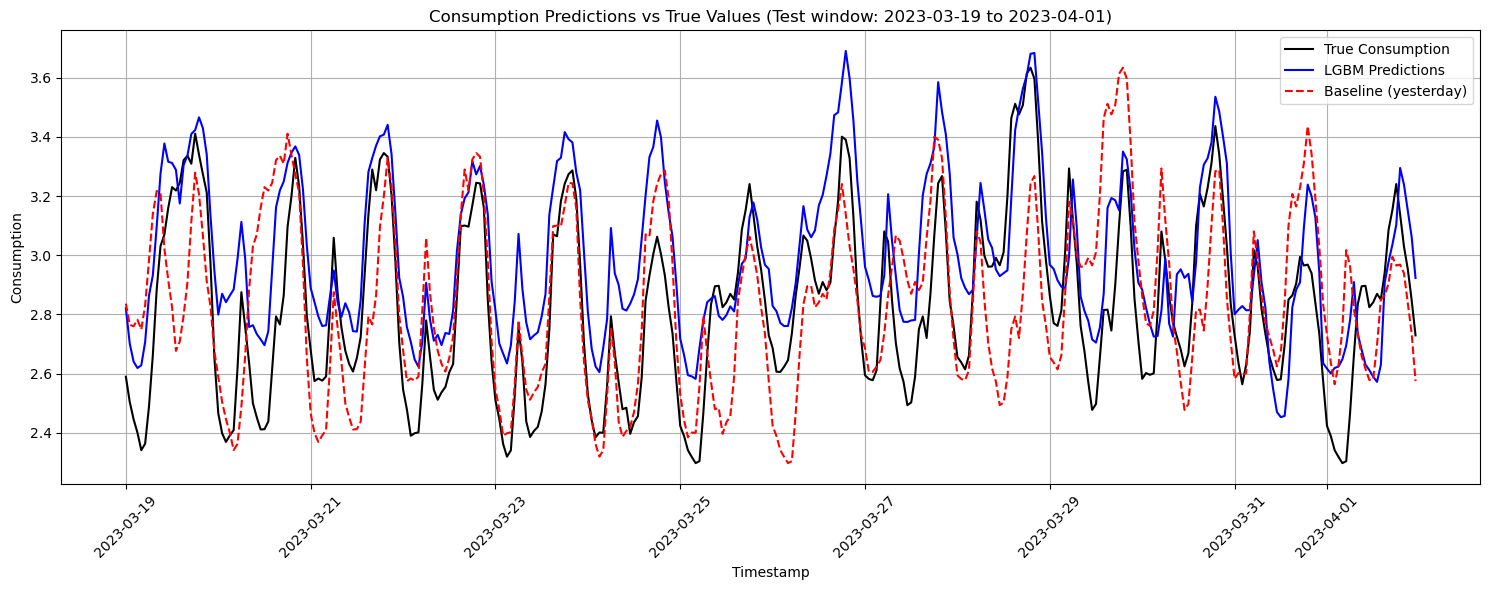

In [15]:
start_ts = pd.Timestamp("2023-03-19")
end_ts = pd.Timestamp("2023-04-02")  # exclusive

test_period = predictions[(predictions["timestamp"] >= start_ts) & (predictions["timestamp"] < end_ts)]
baseline_period = baseline_predictions[(baseline_predictions["timestamp"] >= start_ts) & (baseline_predictions["timestamp"] < end_ts)]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(test_period["timestamp"], test_period["y_true"], label="True Consumption", color="black")
ax.plot(test_period["timestamp"], test_period["y_pred"], label="LGBM Predictions", color="blue")
ax.plot(baseline_period["timestamp"], baseline_period["y_pred"], label="Baseline (yesterday)", color="red", linestyle="--")

ax.set_title("Consumption Predictions vs True Values (Test window: 2023-03-19 to 2023-04-01)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption")
ax.legend()
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,feature,importance_gain,importance_split
21,avail_roll_mean_336,38075.481717,4137
14,temp_roll_mean_168,9955.481181,6578
2,hour_sin,3182.552664,7479
12,temp_roll_mean_24,2775.258852,9727
18,lag_168,2615.179228,16087
17,lag_120,948.444347,14113
0,temperature,761.112496,14107
19,avail_roll_mean_168,601.827170,4787
3,hour_cos,317.574977,7241
6,month_sin,286.448740,448


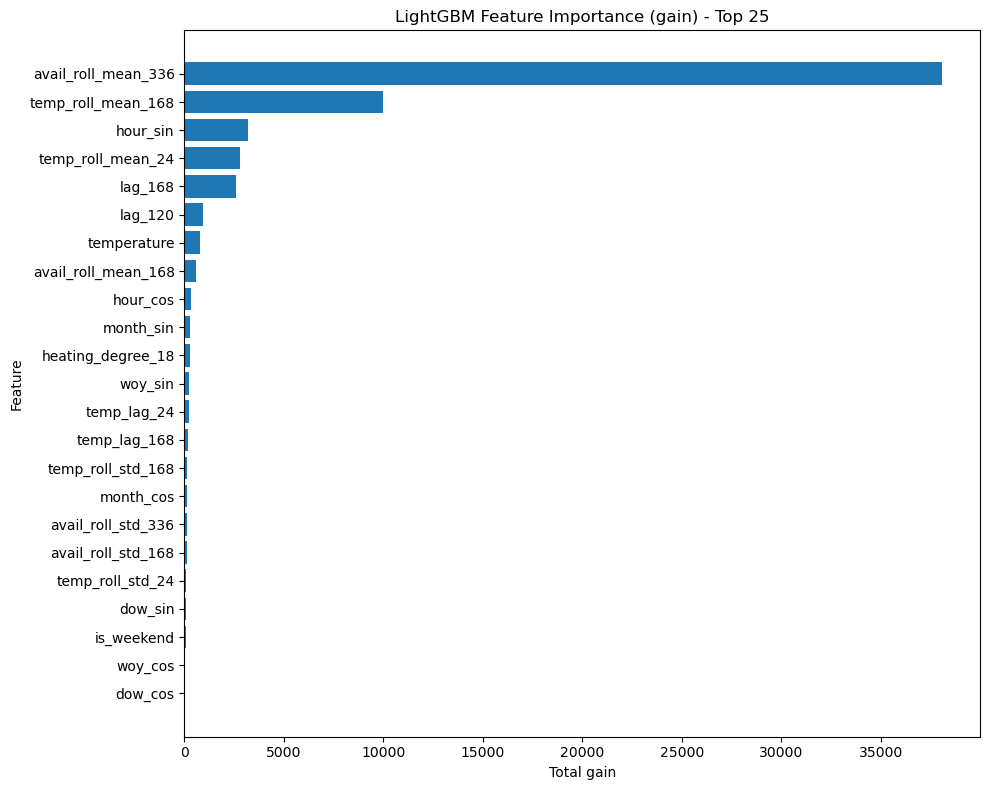

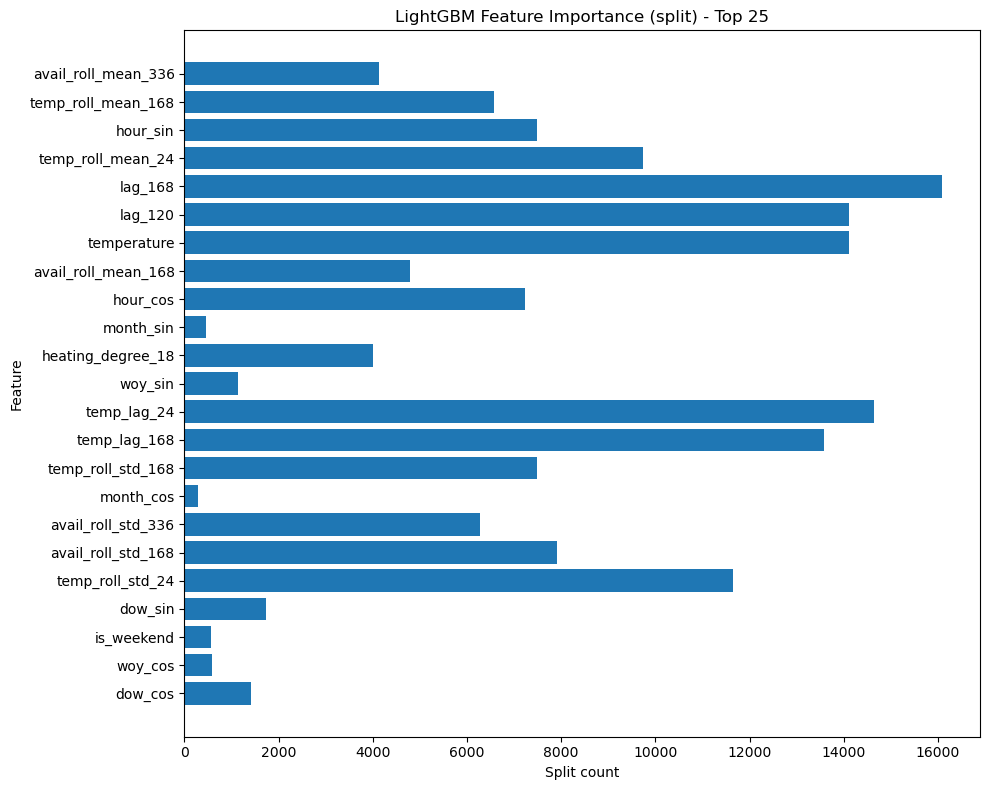

In [16]:
# Feature importance (LightGBM) + diagnostics

# This fits ONE final model on the latest available history before the first test day,
# then plots feature importances (gain + split). This is mainly for interpretation.

# pick a reference day to fit an "analysis model"
# Use the FIRST test split (train+val history right before the test window starts)
ref_split = test_splits[0]

X_fit = pd.concat([ref_split.X_train, ref_split.X_val], axis=0)
y_fit = pd.concat([ref_split.y_train, ref_split.y_val], axis=0)

analysis_model = make_lgbm_model(best_params)
analysis_model.fit(X_fit, y_fit)

booster = analysis_model.booster_

# Importance as arrays
feat_names = booster.feature_name()
imp_gain = booster.feature_importance(importance_type="gain")
imp_split = booster.feature_importance(importance_type="split")

imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance_gain": imp_gain,
    "importance_split": imp_split,
}).sort_values("importance_gain", ascending=False)

display(imp_df.head(30))

# Plot top-N
TOP_N = 25
top = imp_df.head(TOP_N).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top["feature"], top["importance_gain"])
plt.title(f"LightGBM Feature Importance (gain) - Top {TOP_N}")
plt.xlabel("Total gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.barh(top["feature"], top["importance_split"])
plt.title(f"LightGBM Feature Importance (split) - Top {TOP_N}")
plt.xlabel("Split count")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Test

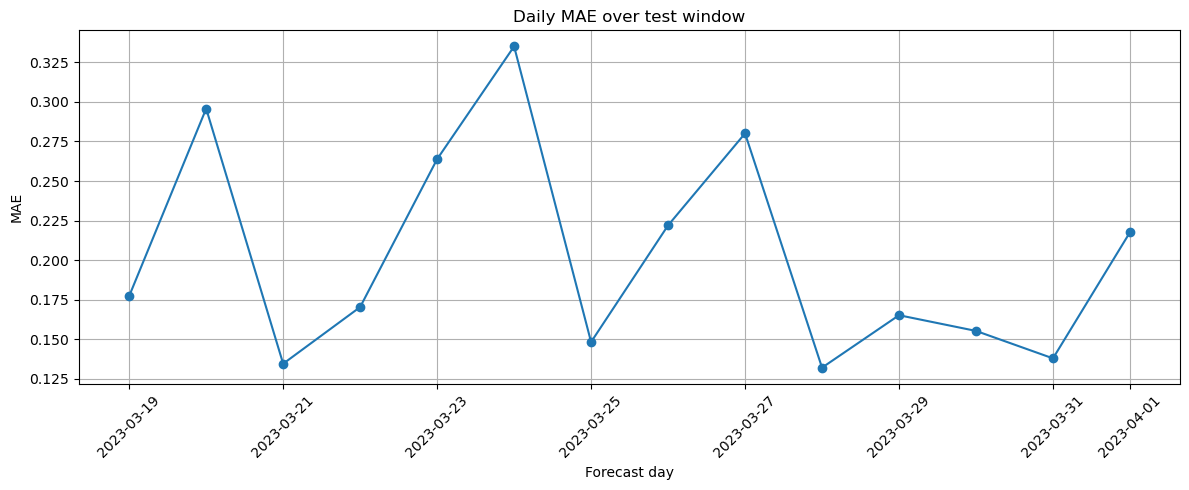

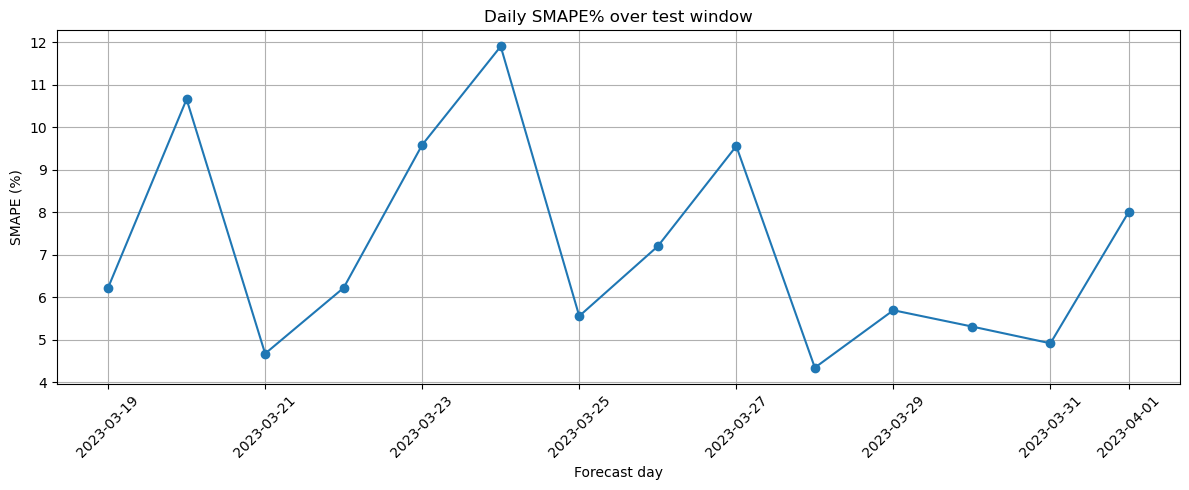

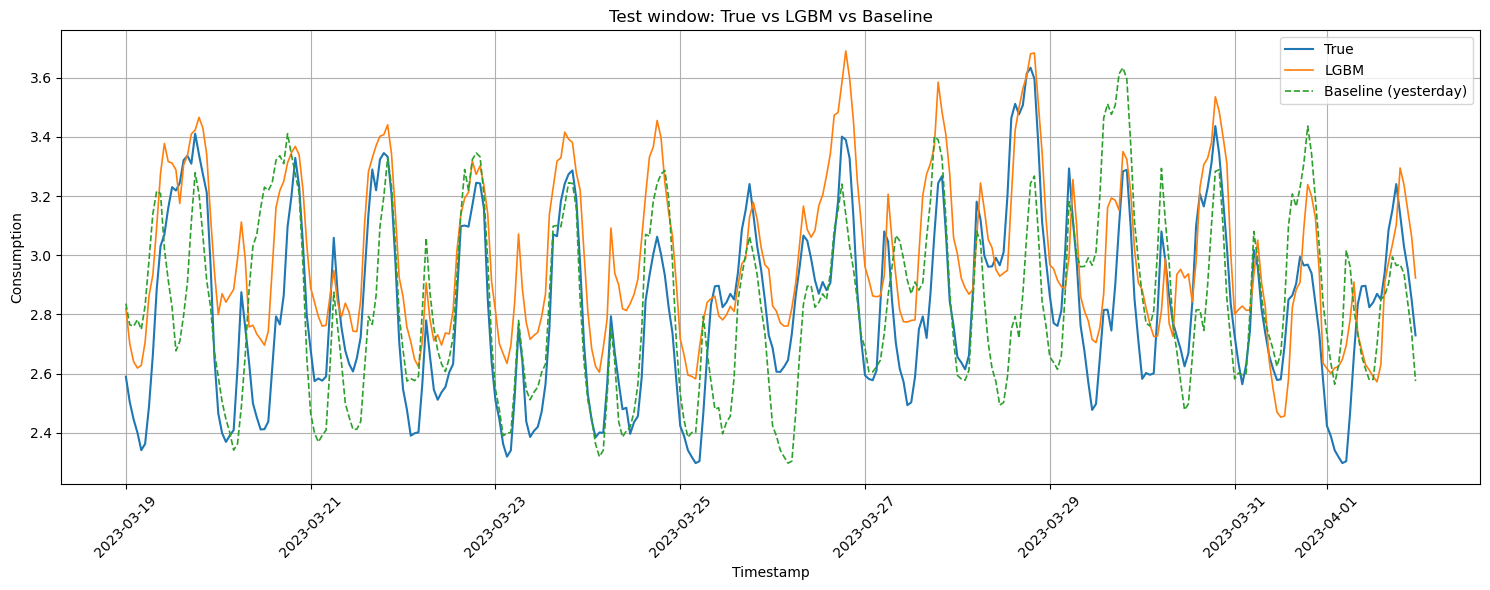

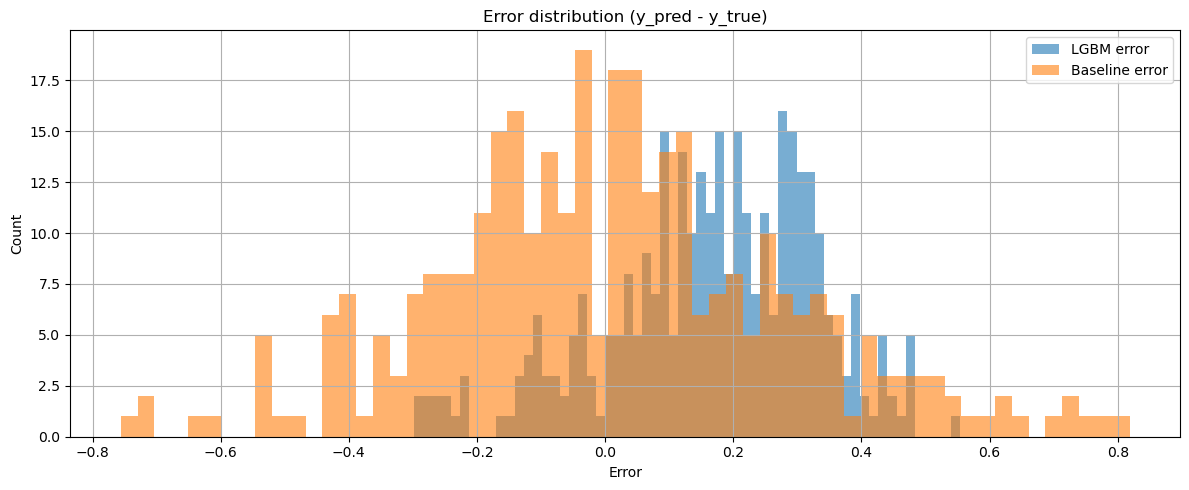

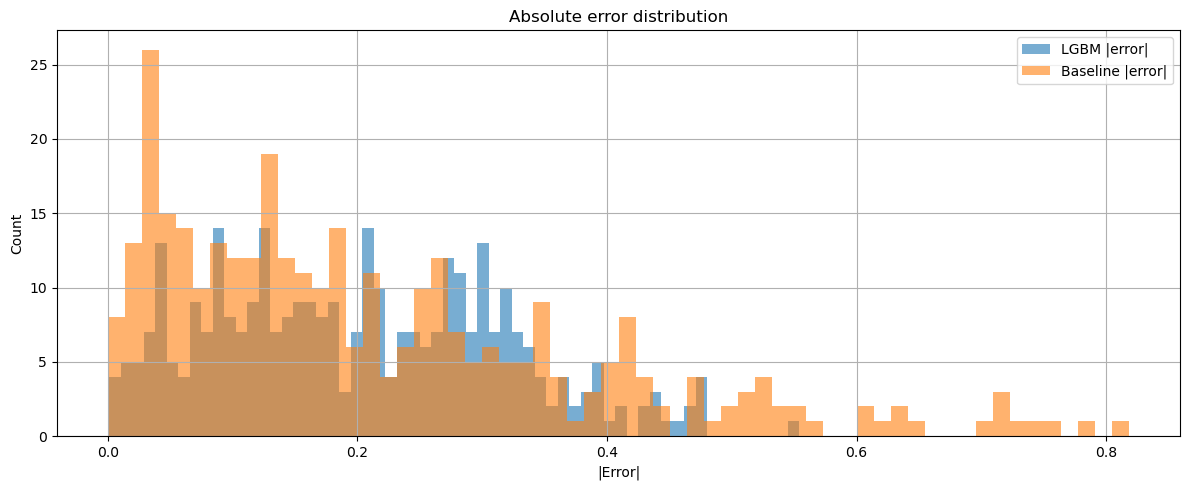

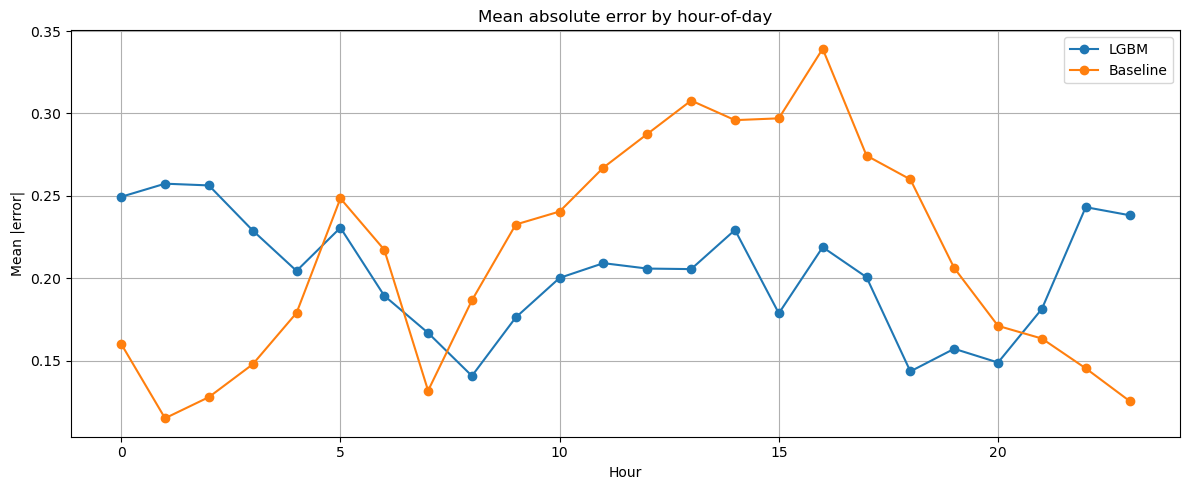

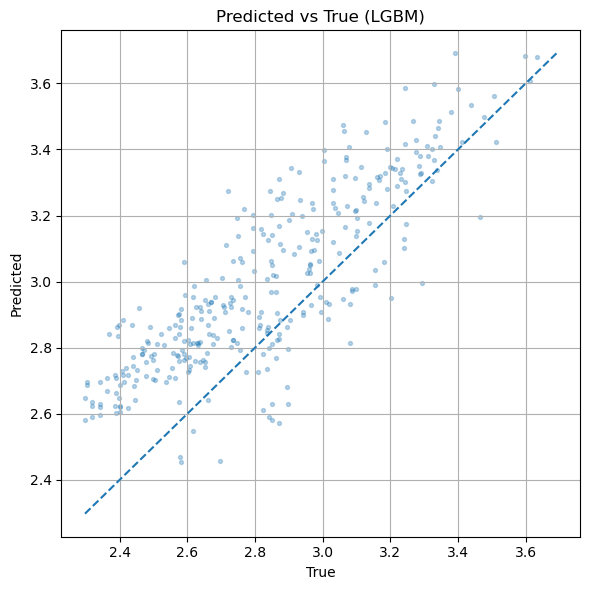

Top 3 worst days (by MAE): [datetime.date(2023, 3, 24), datetime.date(2023, 3, 20), datetime.date(2023, 3, 27)]


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_80607/2488233380.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  day_mae = viz.groupby("date").apply(lambda g: np.mean(np.abs(g["y_pred"] - g["y_true"]))).sort_values(ascending=False)


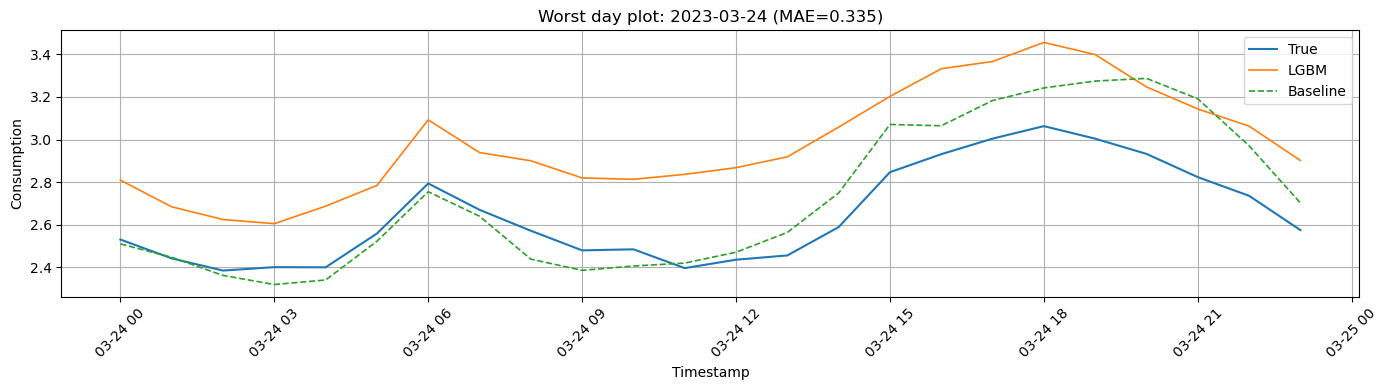

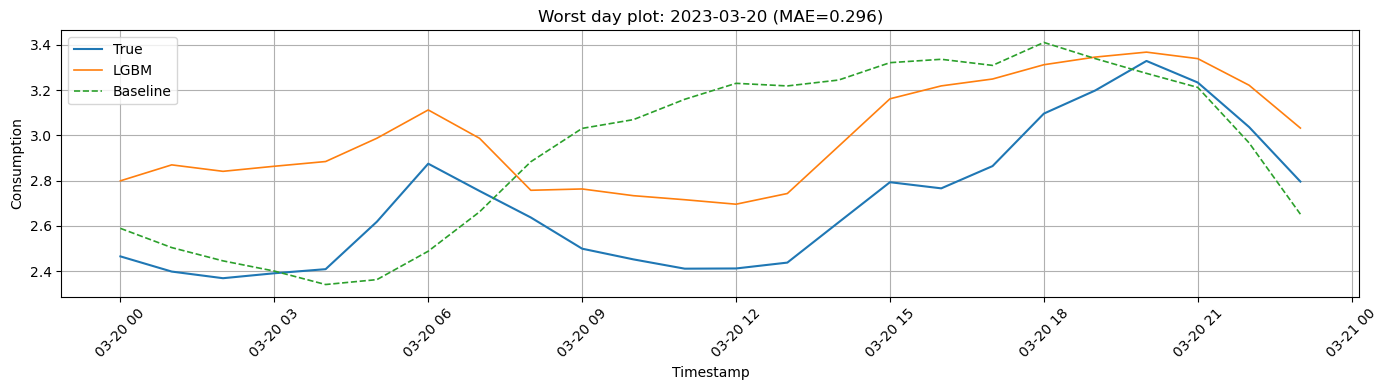

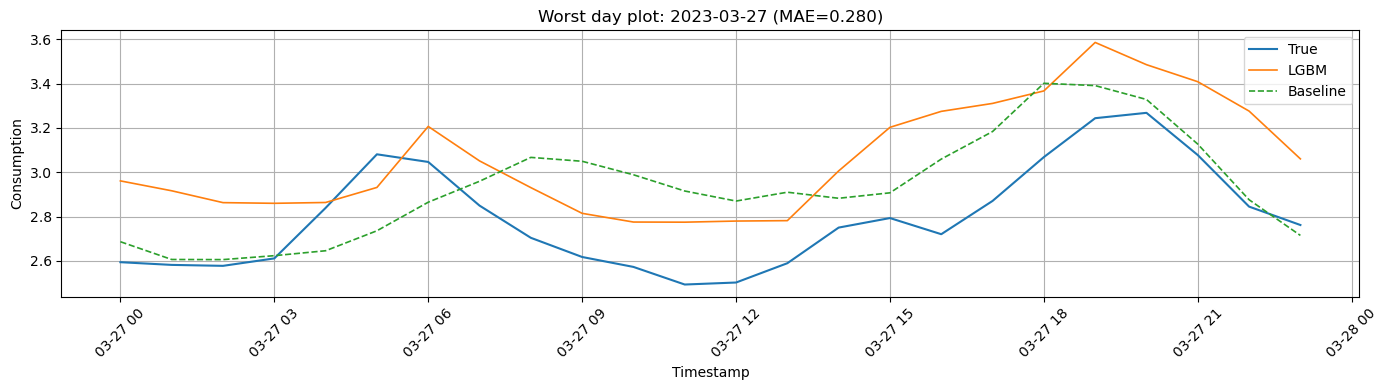

Aggregate MAE: LGBM=0.2026 | Baseline=0.2137 | Improvement=5.20%


In [17]:
# ==========================================
# Test visualizations (better + more views)
# Uses: daily_metrics, predictions, baseline_predictions
# ==========================================

# --- Ensure timestamps are datetime ---
predictions = predictions.copy()
baseline_predictions = baseline_predictions.copy()
predictions["timestamp"] = pd.to_datetime(predictions["timestamp"])
baseline_predictions["timestamp"] = pd.to_datetime(baseline_predictions["timestamp"])

# Align baseline to predictions timestamps (safe)
base_aligned = (
    baseline_predictions[["timestamp", "y_pred"]]
    .rename(columns={"y_pred": "y_pred_baseline"})
    .set_index("timestamp")
)
pred_aligned = predictions.set_index("timestamp")
viz = pred_aligned.join(base_aligned, how="left").reset_index()

# -------------------------
# 1) Daily metrics over time
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(daily_metrics["forecast_date"], daily_metrics["MAE"], marker="o")
plt.title("Daily MAE over test window")
plt.xlabel("Forecast day")
plt.ylabel("MAE")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(daily_metrics["forecast_date"], daily_metrics["SMAPE_%"], marker="o")
plt.title("Daily SMAPE% over test window")
plt.xlabel("Forecast day")
plt.ylabel("SMAPE (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------
# 2) Overall time series: True vs Model vs Baseline
# -------------------------
plt.figure(figsize=(15, 6))
plt.plot(viz["timestamp"], viz["y_true"], label="True", linewidth=1.5)
plt.plot(viz["timestamp"], viz["y_pred"], label="LGBM", linewidth=1.2)
plt.plot(viz["timestamp"], viz["y_pred_baseline"], label="Baseline (yesterday)", linestyle="--", linewidth=1.2)
plt.title("Test window: True vs LGBM vs Baseline")
plt.xlabel("Timestamp")
plt.ylabel("Consumption")
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 3) Error distribution: histogram + CDF-ish view
# -------------------------
err_model = (viz["y_pred"] - viz["y_true"]).dropna()
err_base  = (viz["y_pred_baseline"] - viz["y_true"]).dropna()

plt.figure(figsize=(12, 5))
plt.hist(err_model, bins=60, alpha=0.6, label="LGBM error")
plt.hist(err_base, bins=60, alpha=0.6, label="Baseline error")
plt.title("Error distribution (y_pred - y_true)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

abs_err_model = np.abs(err_model)
abs_err_base  = np.abs(err_base)

plt.figure(figsize=(12, 5))
plt.hist(abs_err_model, bins=60, alpha=0.6, label="LGBM |error|")
plt.hist(abs_err_base, bins=60, alpha=0.6, label="Baseline |error|")
plt.title("Absolute error distribution")
plt.xlabel("|Error|")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 4) Error by hour-of-day (mean absolute error)
# -------------------------
tmp = viz.copy()
tmp["hour"] = tmp["timestamp"].dt.hour
tmp["abs_err_model"] = np.abs(tmp["y_pred"] - tmp["y_true"])
tmp["abs_err_base"]  = np.abs(tmp["y_pred_baseline"] - tmp["y_true"])

hour_mae = tmp.groupby("hour")[["abs_err_model", "abs_err_base"]].mean()

plt.figure(figsize=(12, 5))
plt.plot(hour_mae.index, hour_mae["abs_err_model"], marker="o", label="LGBM")
plt.plot(hour_mae.index, hour_mae["abs_err_base"], marker="o", label="Baseline")
plt.title("Mean absolute error by hour-of-day")
plt.xlabel("Hour")
plt.ylabel("Mean |error|")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 5) Scatter: predicted vs true (sanity check)
# -------------------------
sample = viz.dropna(subset=["y_true", "y_pred"]).sample(min(5000, len(viz)), random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(sample["y_true"], sample["y_pred"], s=8, alpha=0.3)
m = min(sample["y_true"].min(), sample["y_pred"].min())
M = max(sample["y_true"].max(), sample["y_pred"].max())
plt.plot([m, M], [m, M], linestyle="--")
plt.title("Predicted vs True (LGBM)")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# 6) Worst days: plot top 3 by daily MAE (True vs LGBM vs Baseline)
# -------------------------
# Create per-day MAE from predictions for robust selection (uses exact timestamps)
viz["date"] = viz["timestamp"].dt.normalize()
day_mae = viz.groupby("date").apply(lambda g: np.mean(np.abs(g["y_pred"] - g["y_true"]))).sort_values(ascending=False)

top_days = day_mae.head(3).index.tolist()
print("Top 3 worst days (by MAE):", [d.date() for d in top_days])

for d in top_days:
    g = viz[viz["date"] == d].sort_values("timestamp")
    plt.figure(figsize=(14, 4))
    plt.plot(g["timestamp"], g["y_true"], label="True", linewidth=1.5)
    plt.plot(g["timestamp"], g["y_pred"], label="LGBM", linewidth=1.2)
    plt.plot(g["timestamp"], g["y_pred_baseline"], label="Baseline", linestyle="--", linewidth=1.2)
    plt.title(f"Worst day plot: {d.date()} (MAE={day_mae.loc[d]:.3f})")
    plt.xlabel("Timestamp")
    plt.ylabel("Consumption")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# 7) Improvement vs baseline (aggregate)
# -------------------------
model_mae = np.mean(np.abs(viz["y_pred"] - viz["y_true"]))
base_mae  = np.mean(np.abs(viz["y_pred_baseline"] - viz["y_true"]))

print(f"Aggregate MAE: LGBM={model_mae:.4f} | Baseline={base_mae:.4f} | "
      f"Improvement={(base_mae - model_mae)/base_mae*100:.2f}%")
